# Series de tiempo USD/COP — diagnóstico Box-Jenkins

Hasta hoy el sistema usaba **ARIMA(2,1,2) como acto de fe** — un orden hardcodeado sin
mirar la data. Esta notebook hace el proceso correcto y **determina resultados**:

1. **Estacionariedad** — ADF + KPSS (sus hipótesis nulas son opuestas: usarlos juntos evita autoengaños)
2. **ACF / PACF** — ¿qué rezagos tienen memoria real?
3. **Selección de orden por AIC** — que gane la evidencia, no la costumbre
4. **Ljung-Box** sobre residuales — ¿el modelo capturó la estructura?
5. **Backtest direccional comparativo** — ¿el orden elegido predice mejor la *dirección*?

Todo determinista, cero LLM (`src/cop_fx/timeseries/diagnostics.py`).

12:58:17  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


12:58:17  INFO      cop_fx.data.fx_fetcher  —  Fetched 236 FX rows (start=2025-06-12, end=2026-06-12)


236 días de TRM oficial · última: 3,513.54 (2026-06-12)


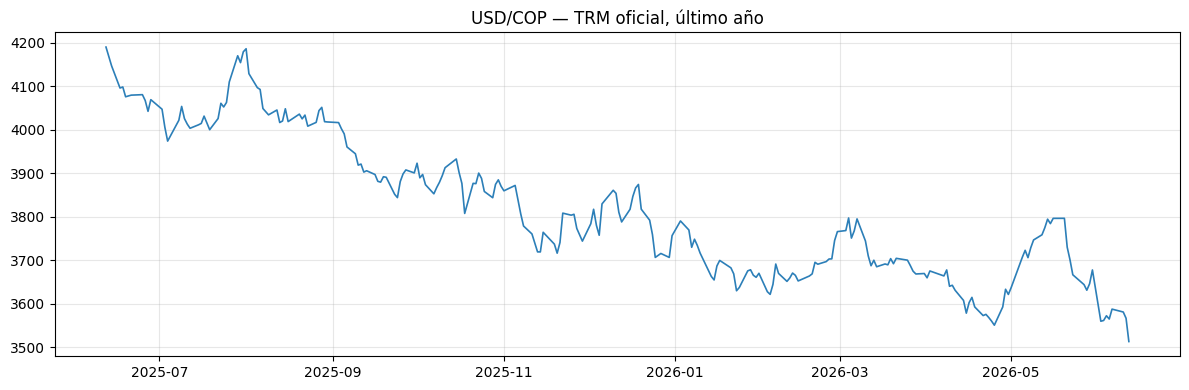

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
load_dotenv(ROOT / ".env")
os.chdir(ROOT)

from cop_fx.data.fx_fetcher import FXFetcher

fx = FXFetcher().fetch(lookback_days=365)
print(f"{len(fx)} días de TRM oficial · última: {fx['y'].iloc[-1]:,.2f} ({fx['ds'].iloc[-1].date()})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fx["ds"], fx["y"], color="#2c7fb8", lw=1.2)
ax.set_title("USD/COP — TRM oficial, último año")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 1. Nivel vs retornos

El **nivel** de un tipo de cambio casi nunca es estacionario (camina). Lo que se modela
son los **retornos logarítmicos** — la variación porcentual diaria. Si los retornos
resultan ser ruido blanco, la serie es un *random walk* y NINGÚN ARIMA podrá predecir
su dirección mejor que una moneda. Esa es la hipótesis a vencer.

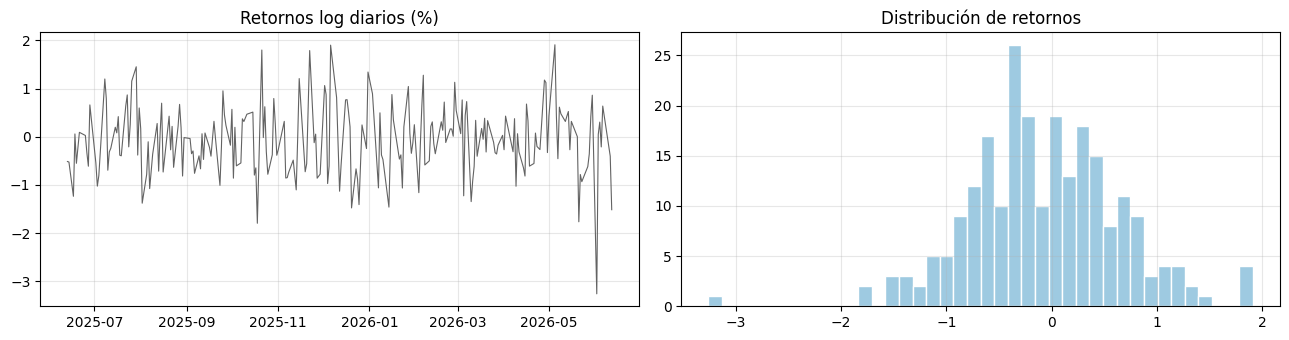

count    235.000
mean      -0.075
std        0.714
min       -3.258
25%       -0.546
50%       -0.119
75%        0.380
max        1.908
skew: -0.139 · curtosis (exceso): 1.377


In [2]:
returns = np.log(fx["y"]).diff().dropna() * 100  # retornos log en %

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(fx["ds"].iloc[1:], returns, lw=0.8, color="#636363")
axes[0].set_title("Retornos log diarios (%)"); axes[0].grid(alpha=0.3)
axes[1].hist(returns, bins=40, color="#9ecae1", edgecolor="white")
axes[1].set_title("Distribución de retornos"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(returns.describe().round(3).to_string())
print(f"skew: {returns.skew():.3f} · curtosis (exceso): {returns.kurtosis():.3f}")

## 2. Estacionariedad — ADF + KPSS

- **ADF**: H0 = hay raíz unitaria (NO estacionaria). p < 0.05 ⇒ rechazo ⇒ estacionaria.
- **KPSS**: H0 = ES estacionaria. p < 0.05 ⇒ rechazo ⇒ NO estacionaria.

Concluimos solo cuando ambos concuerdan.

In [3]:
from cop_fx.timeseries.diagnostics import stationarity_tests, suggest_d

rows = []
for name, s in [("nivel (TRM)", fx["y"]), ("retornos log", returns)]:
    r = stationarity_tests(s)
    rows.append({"serie": name, "ADF p-value": r.adf_pvalue, "KPSS p-value": r.kpss_pvalue,
                 "veredicto": r.verdict})
display(pd.DataFrame(rows))

d = suggest_d(fx["y"])
print(f"\nOrden de diferenciación sugerido por los tests: d = {d}")

Importing plotly failed. Interactive plots will not work.


/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")


,serie,ADF p-value,KPSS p-value,veredicto
0,nivel (TRM),0.5725,0.01,NO estacionaria (ADF y KPSS concuerdan)
1,retornos log,0.0000,0.10,estacionaria (ADF y KPSS concuerdan)



Orden de diferenciación sugerido por los tests: d = 1


/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")


## 3. ACF y PACF de los retornos

La lectura clásica:
- **PACF que corta en el rezago p** → componente AR(p)
- **ACF que corta en el rezago q** → componente MA(q)
- **Ambas dentro de las bandas** → ruido blanco: no hay nada lineal que modelar

Las bandas azules son ±1.96/√n: lo que queda dentro es indistinguible de cero al 95%.

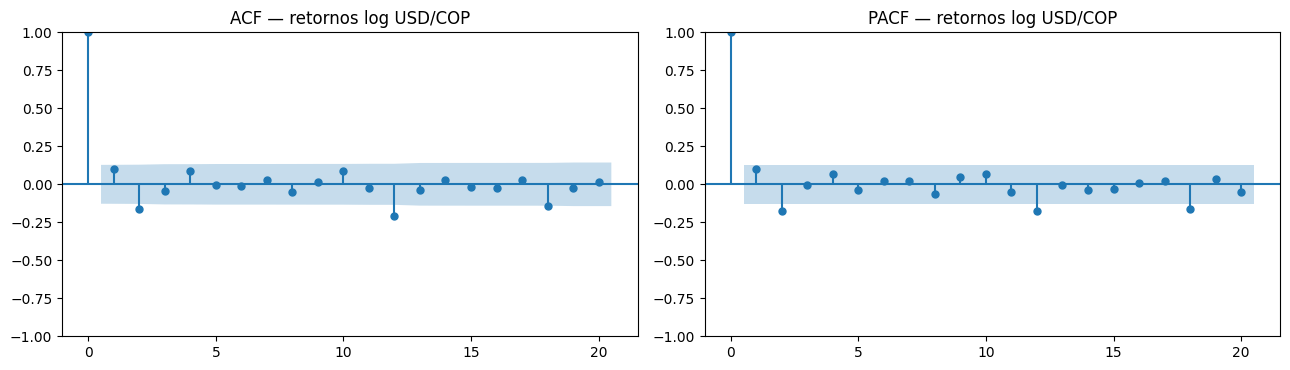

Banda de confianza: ±0.1279
Rezagos ACF significativos : [2, 12, 18]
Rezagos PACF significativos: [2, 12, 18]

(Al 95%, ~1 falso positivo en 20 rezagos es esperable por puro azar.)


In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from cop_fx.timeseries.diagnostics import correlogram

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_acf(returns, lags=20, ax=axes[0], title="ACF — retornos log USD/COP")
plot_pacf(returns, lags=20, ax=axes[1], method="ywm", title="PACF — retornos log USD/COP")
plt.tight_layout(); plt.show()

rep = correlogram(returns, nlags=20)
print(f"Banda de confianza: ±{rep.conf_band}")
print(f"Rezagos ACF significativos : {rep.significant_acf_lags or 'NINGUNO'}")
print(f"Rezagos PACF significativos: {rep.significant_pacf_lags or 'NINGUNO'}")
print("\n(Al 95%, ~1 falso positivo en 20 rezagos es esperable por puro azar.)")

## 4. Selección de orden por AIC

Grid de (p, d, q) con p,q ≤ 3 y el `d` que dictaron los tests. El AIC premia el ajuste
y castiga la complejidad — gana el modelo más parsimonioso que explica la data.

In [5]:
from cop_fx.timeseries.diagnostics import select_arima_order

best_order, table = select_arima_order(fx, max_p=3, max_q=3)
print(f"GANADOR por AIC: ARIMA{best_order}\n")
display(table.head(8))
in_table = table[table["order"].astype(str) == "(2, 1, 2)"]
if not in_table.empty:
    rank = in_table.index[0] + 1
    print(f"El (2,1,2) histórico quedó en el puesto {rank} de {len(table)} (AIC {in_table['aic'].iloc[0]})")

/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/src/cop_fx/timeseries/diagnostics.py:64: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, regression="c", nlags="auto")


12:58:18  INFO      cop_fx.timeseries.diagnostics  —  Orden ARIMA seleccionado por AIC: (2, 1, 3)


GANADOR por AIC: ARIMA(2, 1, 3)



/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,aic,bic
0,"(2, 1, 3)",2212.35,2233.11
1,"(2, 1, 2)",2214.19,2231.48
2,"(3, 1, 2)",2214.37,2235.13
3,"(2, 1, 0)",2216.31,2226.69
4,"(0, 1, 2)",2217.60,2227.97
5,"(3, 1, 3)",2218.12,2242.34
6,"(2, 1, 1)",2218.31,2232.15
7,"(3, 1, 0)",2218.31,2232.14


El (2,1,2) histórico quedó en el puesto 2 de 15 (AIC 2214.19)


## 5. Diagnóstico de residuales — Ljung-Box

H0 = los residuales son ruido blanco (lo deseable: el modelo no dejó estructura).
Comparamos el orden ganador contra el (2,1,2) histórico.

In [6]:
from cop_fx.timeseries.diagnostics import residual_diagnostics

for order in (best_order, (2, 1, 2)):
    r = residual_diagnostics(fx, order)
    print(f"ARIMA{r.order}: AIC={r.aic} · Ljung-Box p={r.ljung_box_pvalue} → {r.verdict}")

/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 1, 3): AIC=2212.35 · Ljung-Box p=1.0 → residuales ≈ ruido blanco — el modelo capturó la estructura lineal
ARIMA(2, 1, 2): AIC=2214.19 · Ljung-Box p=1.0 → residuales ≈ ruido blanco — el modelo capturó la estructura lineal


## 6. Backtest direccional comparativo — el resultado que importa

El AIC mide ajuste in-sample; nuestro negocio es la **dirección out-of-sample**.
Rolling-origin sobre los últimos 40 días, horizonte 5: ¿el orden elegido por la
evidencia le gana al (2,1,2) de fe? ¿Y a momentum?

In [7]:
from cop_fx.tracking import directional_backtest

results = {}
for label, order in [(f"ARIMA{best_order} (AIC)", best_order), ("ARIMA(2,1,2) (histórico)", (2, 1, 2))]:
    _, summary = directional_backtest(fx, horizon_days=5, n_origins=40, arima_order=order)
    s = summary["arima"]
    results[label] = s
    results.setdefault("momentum", summary["momentum"])
    results.setdefault("always_up", summary["always_up"])

rows = [{"estrategia": k,
         "hit_rate": f"{v['hit_rate']:.0%}" if v["hit_rate"] is not None else "—",
         "decisiones": v["n_decided"], "abstenciones": v["n_abstained"]}
        for k, v in results.items()]
display(pd.DataFrame(rows))

12:58:18  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3664.41, day+5=3668.18


12:58:19  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3678.19, day+5=3679.99


12:58:19  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3640.63, day+5=3646.68


12:58:19  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3642.93, day+5=3648.58


12:58:19  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3642.93, day+5=3648.58


...

12:58:23  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3646.58, day+5=3645.74


12:58:23  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3560.24, day+5=3559.13


12:58:23  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3562.00, day+5=3572.94


12:58:23  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3572.85, day+5=3567.83


,estrategia,hit_rate,decisiones,abstenciones
0,"ARIMA(2, 1, 3) (AIC)",35%,26,14
1,momentum,53%,36,4
2,always_up,42%,40,0
3,"ARIMA(2,1,2) (histórico)",52%,25,15


## Conclusiones — cómo leer estos resultados

1. **Si los retornos no tienen rezagos significativos** (ACF/PACF dentro de bandas) y
   Ljung-Box no rechaza, la TRM diaria es ≈ random walk: la *estructura lineal* no da
   ventaja direccional. Eso **no es un fracaso del proyecto** — es la razón por la que
   el sistema cruza la serie con NOTICIAS y se permite **abstenerse**: la ventaja, si
   existe, está en los días con shock informativo, no en la inercia de la serie.
2. **El orden por AIC reemplaza al acto de fe**: aunque no mejore mucho el hit-rate,
   ahora el modelo está justificado por la evidencia y el diagnóstico es reproducible
   (`select_arima_order` puede correr en cada corrida si se quisiera).
3. **La banda muerta (±0.1%) y las abstenciones** del backtest son tan informativas como
   los aciertos: un modelo que dice "no sé" en mercado lateral es mejor que uno que
   fuerza una moneda.
4. Siguiente refuerzo natural de esta pata: **GARCH para volatilidad** (la confianza del
   adjudicador podría escalar con la volatilidad esperada) y variables exógenas
   (Brent, DXY) en un ARIMAX — ver `docs/arquitectura.md` §2.

---
## Resultados de esta corrida (2026-06-12) — lo que la data dijo

| Pregunta | Respuesta |
|---|---|
| ¿El nivel es estacionario? | **No** (ADF p=0.57, KPSS p=0.01 concuerdan) → `d=1` ✓ |
| ¿Los retornos son estacionarios? | **Sí** (ADF p≈0, KPSS p=0.10 concuerdan) |
| ¿Hay memoria lineal? | **Débil pero existe**: rezago 2 significativo en ACF **y** PACF (12 y 18 probablemente espurios) — la TRM no es un random walk puro |
| ¿Qué orden gana por AIC? | `(2,1,3)` por nariz (2212.35 vs 2214.19) — pero por **BIC** gana `(2,1,2)` |
| ¿Residuales limpios? | Ambos órdenes dejan ruido blanco (Ljung-Box p=1.0) |
| ¿Y out-of-sample? | **`(2,1,3)` se desploma a 35%** mientras `(2,1,2)` mantiene **52%** |

**La lección (apréndetela, vale más que el resultado):** el mejor AIC in-sample NO es el
mejor modelo out-of-sample. El parámetro MA extra del `(2,1,3)` ajustó ruido, no señal —
overfitting de libro de texto. El BIC (que castiga más la complejidad) ya lo advertía.

**Decisión:** el sistema CONSERVA `ARIMA(2,1,2)` — pero ya no como acto de fe, sino como
el orden respaldado por BIC, residuales limpios y el mejor hit-rate direccional
out-of-sample. El diagnóstico queda en `cop_fx.timeseries.diagnostics` para re-auditarlo
cuando la serie acumule más historia.